**Diagram Konceptualny**

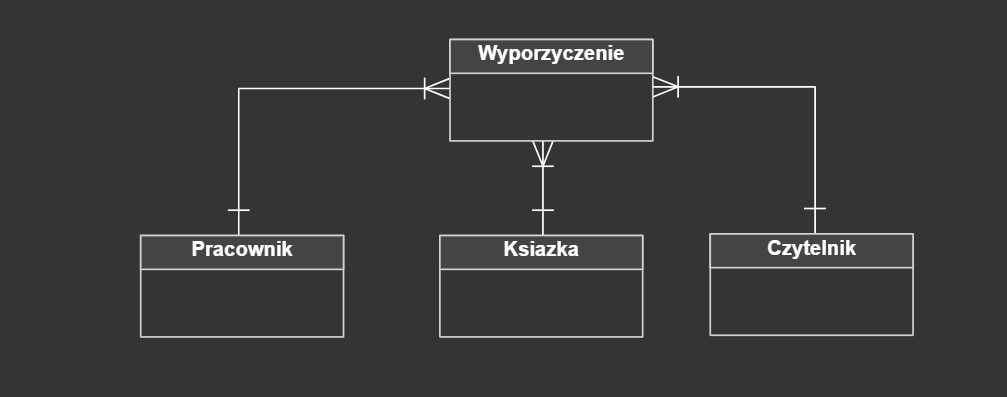  

**Diagram Implementacyjny**

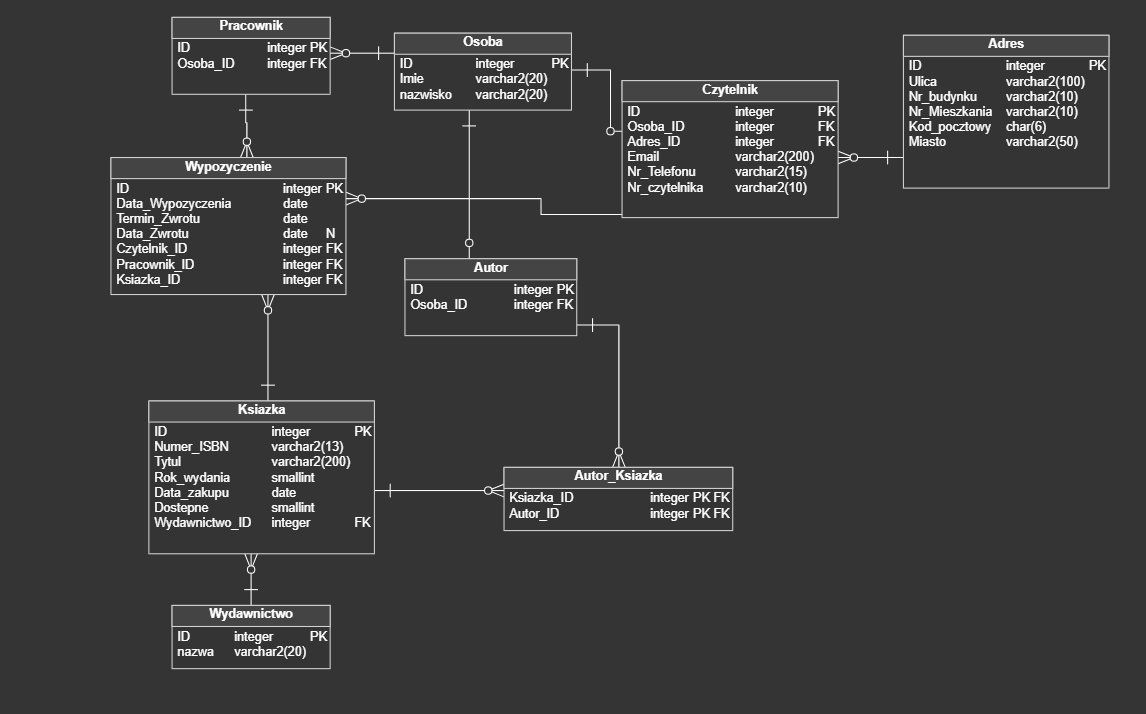

<span style="font-size: 15px;"><b>Zapisz polecenie w języku SQL, które założy pliki bazy danych MS SQL. Pliki powinny znajdować się w lokalizacji C:\BD i nie powinny przekraczać 512 MB.</b></span>

In [29]:
USE master;
--użyłem innej lokalizacji na moim komputerze przez problemy z dockerem i WSL
GO
CREATE DATABASE biblioteka
ON
( NAME = biblioteka_dat,
--FILENAME = 'C:\BD\biblioteka_dat.mdf',
  FILENAME = '/var/opt/mssql/data/biblioteka_dat.mdf',
  MAXSIZE = 512MB,
  FILEGROWTH = 8MB )
LOG ON
( NAME = biblioteka_log,
--FILENAME = 'C:\BD\biblioteka_log.ldf'
  FILENAME = '/var/opt/mssql/data/biblioteka_log.ldf',
  MAXSIZE = 512MB,
  FILEGROWTH = 8MB );
GO


Commands completed successfully.

: Msg 1801, Level 16, State 3, Line 3
Database 'biblioteka' already exists. Choose a different database name.

Total execution time: 00:00:00.003

**Załóżmy ze pracować będziemy w środowisku ADS a silnik bazy danych MS SQL znajduje się na maszynie lokalnej. Zapisz polecenie nawiązujące połączenia środowiska ADS do bazy danych z punktu 2. Zwróć uwagę na poprawną składnię polecenia.**  

Server=localhost;Persist Security Info=False;User ID=sa;Password=PASSWORDand;MultipleActiveResultSets=False;Encrypt=True;TrustServerCertificate=False;Connection Timeout=30;

**Tworzenie Tabel, indeksów oraz powiązań**

In [30]:

-- Tabela: Adres
USE biblioteka
CREATE TABLE Adres (
    ID integer  NOT NULL,
    Ulica varchar(100)  NOT NULL,
    Nr_budynku varchar(10)  NOT NULL,
    Nr_Mieszkania varchar(10)  NOT NULL,
    Kod_pocztowy char(6)  NOT NULL,
    Miasto varchar(50)  NOT NULL,
    CONSTRAINT Adres_pk PRIMARY KEY (ID)
) ;

-- Tabela: Autor
CREATE TABLE Autor (
    ID integer  NOT NULL,
    Osoba_ID integer  NOT NULL,
    CONSTRAINT Autor_pk PRIMARY KEY (ID)
) ;

-- Tabela: Autor_Ksiazka
CREATE TABLE Autor_Ksiazka (
    Ksiazka_ID integer  NOT NULL,
    Autor_ID integer  NOT NULL,
    CONSTRAINT Autor_Ksiazka_pk PRIMARY KEY (Ksiazka_ID,Autor_ID)
) ;

-- Tabela: Czytelnik
CREATE TABLE Czytelnik (
    ID integer  NOT NULL,
    Nr_czytelnika varchar(10) NOT NULL,
    Osoba_ID integer  NOT NULL,
    Adres_ID integer  NOT NULL,
    Email varchar(200)  NOT NULL,
    Nr_Telefonu varchar(30)  NOT NULL,
    CONSTRAINT Czytelnik_pk PRIMARY KEY (ID)
) ;

CREATE UNIQUE INDEX idx_czytelnik_email 
on Czytelnik 
(Email ASC)
;

-- Tabela: Ksiazka
CREATE TABLE Ksiazka (
    ID integer  NOT NULL,
    Numer_ISBN varchar(13)  NOT NULL,
    Tytul varchar(200)  NOT NULL,
    Rok_wydania smallint  NOT NULL,
    Data_zakupu date  NOT NULL,
    Dostepne smallint  NOT NULL CHECK (Dostepne >= 0),
    Wydawnictwo_ID integer  NOT NULL,
    CONSTRAINT Ksiazka_pk PRIMARY KEY (ID)
) ;

CREATE UNIQUE INDEX idx_ksiazka_isbn 
on Ksiazka 
(Numer_ISBN ASC)
;

-- Tabela: Osoba
CREATE TABLE Osoba (
    ID integer  NOT NULL,
    Imie varchar(20)  NOT NULL,
    nazwisko varchar(20)  NOT NULL,
    CONSTRAINT Osoba_pk PRIMARY KEY (ID)
) ;

-- Tabela: Pracownik
CREATE TABLE Pracownik (
    ID integer  NOT NULL,
    Osoba_ID integer  NOT NULL,
    CONSTRAINT Pracownik_pk PRIMARY KEY (ID)
) ;

-- Tabela: Wydawnictwo
CREATE TABLE Wydawnictwo (
    ID integer  NOT NULL,
    nazwa varchar(20)  NOT NULL,
    CONSTRAINT Wydawnictwo_pk PRIMARY KEY (ID)
) ;

-- Tabela: Wypozyczenie
CREATE TABLE Wypozyczenie (
    ID integer  NOT NULL,
    Data_Wypozyczenia date  NOT NULL,
    Termin_Zwrotu date  NOT NULL,
    Data_Zwrotu date  NULL,
    Czytelnik_ID integer  NOT NULL,
    Pracownik_ID integer  NOT NULL,
    Ksiazka_ID integer  NOT NULL,
    CONSTRAINT Wypozyczenie_pk PRIMARY KEY (ID)
) ;

-- foreign keys
-- referencja: Autor_Ksiazka_Autor (tabela: Autor_Ksiazka)
ALTER TABLE Autor_Ksiazka ADD CONSTRAINT Autor_Ksiazka_Autor
    FOREIGN KEY (Autor_ID)
    REFERENCES Autor (ID);

-- referencja: Autor_Ksiazka_Ksiazka (tabela: Autor_Ksiazka)
ALTER TABLE Autor_Ksiazka ADD CONSTRAINT Autor_Ksiazka_Ksiazka
    FOREIGN KEY (Ksiazka_ID)
    REFERENCES Ksiazka (ID);

-- referencja: Autor_Osoba (tabela: Autor)
ALTER TABLE Autor ADD CONSTRAINT Autor_Osoba
    FOREIGN KEY (Osoba_ID)
    REFERENCES Osoba (ID);

-- referencja: Czytelnik_Dane (tabela: Czytelnik)
ALTER TABLE Czytelnik ADD CONSTRAINT Czytelnik_Dane
    FOREIGN KEY (Adres_ID)
    REFERENCES Adres (ID);

-- referencja: Czytelnik_Osoba (tabela: Czytelnik)
ALTER TABLE Czytelnik ADD CONSTRAINT Czytelnik_Osoba
    FOREIGN KEY (Osoba_ID)
    REFERENCES Osoba (ID);

-- referencja: Ksiazka_Wydawnictwo (tabela: Ksiazka)
ALTER TABLE Ksiazka ADD CONSTRAINT Ksiazka_Wydawnictwo
    FOREIGN KEY (Wydawnictwo_ID)
    REFERENCES Wydawnictwo (ID);

-- referencja: Pracownik_Osoba (tabela: Pracownik)
ALTER TABLE Pracownik ADD CONSTRAINT Pracownik_Osoba
    FOREIGN KEY (Osoba_ID)
    REFERENCES Osoba (ID);

-- referencja: Wypozyczenie_Czytelnik (tabela: Wypozyczenie)
ALTER TABLE Wypozyczenie ADD CONSTRAINT Wypozyczenie_Czytelnik
    FOREIGN KEY (Czytelnik_ID)
    REFERENCES Czytelnik (ID);

-- referencja: Wypozyczenie_Ksiazka (tabela: Wypozyczenie)
ALTER TABLE Wypozyczenie ADD CONSTRAINT Wypozyczenie_Ksiazka
    FOREIGN KEY (Ksiazka_ID)
    REFERENCES Ksiazka (ID);

-- referencja: Wypozyczenie_Pracownik (tabela: Wypozyczenie)
ALTER TABLE Wypozyczenie ADD CONSTRAINT Wypozyczenie_Pracownik
    FOREIGN KEY (Pracownik_ID)
    REFERENCES Pracownik (ID);



: Msg 2714, Level 16, State 6, Line 4
There is already an object named 'Adres' in the database.

Total execution time: 00:00:00.004

**Wprowadzenie danych testowych**

**Dane tekstowe wygenerowałem na stronie w formie INSERT INTO i uruchomiłem  polecenia w Query**

**np: INSERT INTO dbo.Wypozyczenie (ID, Data\_Wypozyczenia, Termin\_Zwrotu, Data\_Zwrotu, Czytelnik\_ID, Pracownik\_ID, Ksiazka\_ID) VALUES (1008, '2025-01-10', '2025-01-21', '2025-01-12', 47, 10, 1);**

**Zapisz polecenie w języku SQL, które pozwolą na sprawdzenie czy czytelnik o podanym identyfikatorze przekroczył liczbę dopuszczalnych wypożyczeń.**

In [44]:
USE biblioteka
DECLARE @czytelnik VARCHAR(10);
-- Bibliotekarz podaje numer czytelnika do zmiennej
SELECT @czytelnik = '3201507563';
--1832276439
DECLARE @Ilosc INT;
-- Sprawdzenie liczby wypożyczeń dla danego czytelnika
SELECT @Ilosc = (
    SELECT COUNT(*)
    FROM dbo.Wypozyczenie
    INNER JOIN dbo.Czytelnik ON dbo.Wypozyczenie.Czytelnik_ID = dbo.Czytelnik.ID
    WHERE dbo.Czytelnik.Nr_czytelnika = @czytelnik AND dbo.Wypozyczenie.Data_Zwrotu IS NULL
);

DECLARE @odpowiedz VARCHAR(3);
-- Sprawdzenie, czy czytelnik ma wypożyczone więcej niż 5 książek
IF @Ilosc >= 5
    SELECT @odpowiedz = 'nie';
ELSE
    SELECT @odpowiedz = 'tak';

-- Wyświetlenie odpowiedzi
SELECT 
    @czytelnik AS 'Numer czytelnika',
    @odpowiedz AS 'Czy czytelnik może wyporzyczyc ksiazke?';


(1 row affected)

Total execution time: 00:00:00.012

Numer czytelnika,Czy czytelnik może wyporzyczyc ksiazke?
1832276439,tak


**Zapisz polecenie w języku SQL, które pozwolą na sprawdzenie czy książka o podanym numerze ISBN lub tytule i autorze jest dostępna, a jeśli nie to kiedy jej egzemplarz powinien być zwrócony do biblioteki**

In [48]:
USE biblioteka
DECLARE @isbn VARCHAR(13);
DECLARE @tytul VARCHAR(200);
DECLARE @autor_id INT;

-- Bibliotekarz podaje do zmiennych ISBN LUB tytuł ORAZ ID autora
SELECT @isbn = '1404904483432';
SELECT @tytul = '.';
SELECT @autor_id = '';
--One military single.2024  1953166044226
--Development.1404904483432
DECLARE @dostepna DATE;

--sprawdzenie czy data zwrotu ksiazki jest podana, jesli tak - ksiazka jest caly czas u innego uzytkownika
SELECT @dostepna = (
    SELECT TOP (1) Data_Zwrotu
    FROM dbo.Wypozyczenie
    INNER JOIN dbo.Ksiazka ON dbo.Wypozyczenie.Ksiazka_ID = dbo.Ksiazka.ID
    INNER JOIN dbo.Autor_Ksiazka ON dbo.Ksiazka.ID = dbo.Autor_Ksiazka.Ksiazka_ID
    INNER JOIN dbo.Autor ON dbo.Autor_Ksiazka.Autor_ID = dbo.Autor.ID
    WHERE dbo.Ksiazka.Numer_ISBN = @isbn 
        OR (dbo.Ksiazka.Tytul = @tytul AND dbo.Autor.ID = @autor_id)
    ORDER BY dbo.Wypozyczenie.Data_Wypozyczenia DESC
);

-- Sprawdzenie, czy książka jest dostępna
IF @dostepna IS NOT NULL
    SELECT 'ksiazka jest dostepna' AS "czy dostepna?";
ELSE
BEGIN
    DECLARE @data DATE;

    -- Jeśli nie, sprawdzamy datę zwrotu książki
    SELECT @data = (
        SELECT TOP (1) Termin_Zwrotu
        FROM dbo.Wypozyczenie
        INNER JOIN dbo.Ksiazka ON dbo.Wypozyczenie.Ksiazka_ID = dbo.Ksiazka.ID
        INNER JOIN dbo.Autor_Ksiazka ON dbo.Ksiazka.ID = dbo.Autor_Ksiazka.Ksiazka_ID
        INNER JOIN dbo.Autor ON dbo.Autor_Ksiazka.Autor_ID = dbo.Autor.ID
        WHERE dbo.Ksiazka.Numer_ISBN = @isbn 
            OR (dbo.Ksiazka.Tytul = @tytul AND dbo.Autor.ID = @autor_id)
        ORDER BY dbo.Wypozyczenie.Data_Wypozyczenia DESC
    );

    SELECT 'ksiazka jest niedostepna' AS "czy dostepna?", @data AS "kiedy bedzie dostepna?";
END;


(1 row affected)

Total execution time: 00:00:00.141

czy dostepna?
ksiazka jest dostepna


<span style="font-size: 15px;"><b>Zapisz polecenie w języku SQL, które pozwolą na przejrzenie historii wypożyczeń czytelnika o podanym przez operatora numerze</b></span>

In [49]:
USE biblioteka
DECLARE @czytelnik VARCHAR(10);
-- Bibliotekarz podaje numer czytelnika do zmiennej
SELECT @czytelnik = '7178698143';
--3201507563 nie zwrócone
-- Historia wypożyczonych przez użytkownika tytułów
SELECT 
    Czytelnik.Nr_czytelnika AS 'Numer czytelnika', 
    Ksiazka.Tytul AS 'Tytuł książki', 
    Wypozyczenie.Data_Wypozyczenia AS 'Data wypożyczenia', 
    Wypozyczenie.Termin_Zwrotu AS 'Termin zwrotu', 
    Wypozyczenie.Data_Zwrotu AS 'Data zwrotu'
FROM 
    dbo.Ksiazka
INNER JOIN 
    dbo.Wypozyczenie ON Wypozyczenie.Ksiazka_ID = Ksiazka.ID
INNER JOIN 
    dbo.Czytelnik ON Czytelnik.ID = Wypozyczenie.Czytelnik_ID
WHERE 
    Czytelnik.Nr_czytelnika = @czytelnik;


(2 rows affected)

Total execution time: 00:00:00.042

Numer czytelnika,Tytuł książki,Data wypożyczenia,Termin zwrotu,Data zwrotu
7178698143,She responsibility.,2025-01-05,2025-01-04,2025-01-22
7178698143,At candidate there.,2025-01-05,2025-01-04,2025-01-22


<span style="font-size: 15px;"><b>Zapisz polecenie w języku SQL, które pozwolą na podanie listy TOP10 najchętniej wypożyczanych tytułów w ostatnich 6 miesiącach.</b></span>

In [34]:
USE biblioteka
SELECT TOP(10) 
    t.Tytul AS "Najchętniej wypożyczane książki ostatnich 6 miesięcy"
FROM
    -- Wybór wypożyczeń tylko z ostatnich 6 miesięcy
    (SELECT k.Tytul, w.Ksiazka_ID
     FROM dbo.Wypozyczenie AS w
     INNER JOIN dbo.Ksiazka AS k ON w.Ksiazka_ID = k.ID
     WHERE w.Data_Wypozyczenia >= DATEADD(MONTH, -6, GETDATE())) AS t
-- Grupowanie danych po tytule
GROUP BY t.Tytul
-- Sortowanie malejąco, aby uzyskać najczęściej wypożyczane tytuły
ORDER BY COUNT(t.Ksiazka_ID) DESC;


(10 rows affected)

Total execution time: 00:00:00.007

Najchętniej wypożyczane książki ostatnich 6 miesięcy
At candidate there.
Hear simple pattern.
Picture building.
Upon PM in apply.
At poor consumer.
Heavy cultural else.
Lead cultural worry.
Majority recognize.
Make particularly.
Move economy middle.


**Jakie konektory bazodanowe można zastosować w ADS – wymień przynajmniej dwa.**  

**\-**<span style="color: var(--vscode-foreground);">MSSQL&nbsp;</span> 

\-ODBC

\-JDBC

**Wyjaśnij czym jest plik .ipynb Czy jest to plik binarny czy tekstowy? Uzasadnij:** 

Plik .ipynb jest plikiem tekstowym zapisanym w formacie JSON. W pliku .ipynb kod, tekst, obrazy i wyniki obliczeń są przechowywane w strukturze JSON, co umożliwia łatwe udostępnianie i przenoszenie zawartości pomiędzy różnymi platformami i narzędziami. Można go otworzyć za pomocą edytora tekstu i zobaczyć jego zawartość